<a href="https://colab.research.google.com/github/majo581/TALLERES/blob/main/teller_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Precios de teléfonos inteligentes usados
María José González serrano

## 1.Exportacion de datos
Datos sacados de:


*     https://www.kaggle.com/datasets/ahsan81/used-handheld-device-data


 SUBIR BASE DE DATOS DE LA CARPETA DADA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_telefonos = pd.read_excel('used_device_data.xlsx')

In [ ]:
df_telefonos = df_telefonos.iloc[:, 0].str.split(",", expand=True)

In [ ]:
df = pd.read_excel("used_device_data.xlsx", header=None)

# Separar los datos por comas
df_telefonos = df[0].str.split(",", expand=True)

# Usar la primera fila como nombres de columnas
df_telefonos.columns = df_telefonos.iloc[0]

# Eliminar la primera fila
df_telefonos = df_telefonos.iloc[1:].reset_index(drop=True)

In [ ]:
print(df_telefonos.shape)
print(df_telefonos.head())

(3454, 15)
0 device_brand       os screen_size   4g   5g rear_camera_mp front_camera_mp  \
0        Honor  Android        14.5  yes   no             13               5   
1        Honor  Android        17.3  yes  yes             13              16   
2        Honor  Android       16.69  yes  yes             13               8   
3        Honor  Android        25.5  yes  yes             13               8   
4        Honor  Android       15.32  yes   no             13               8   

0 internal_memory ram battery weight release_year days_used  \
0              64   3    3020    146         2020       127   
1             128   8    4300    213         2020       325   
2             128   8    4200    213         2020       162   
3              64   6    7250    480         2020       345   
4              64   3    5000    185         2020       293   

0 normalized_used_price normalized_new_price  
0           4.307572449          4.715100245  
1           5.162096647          5.

In [ ]:
print(df_telefonos)

0    device_brand       os screen_size   4g   5g rear_camera_mp  \
0           Honor  Android        14.5  yes   no             13   
1           Honor  Android        17.3  yes  yes             13   
2           Honor  Android       16.69  yes  yes             13   
3           Honor  Android        25.5  yes  yes             13   
4           Honor  Android       15.32  yes   no             13   
5           Honor  Android       16.23  yes   no             13   
6           Honor  Android       13.84  yes   no              8   
7           Honor  Android       15.77  yes   no             13   
8           Honor  Android       15.32  yes   no             13   
9           Honor  Android       16.23  yes   no             13   
10          Honor  Android       15.47  yes   no             13   
11          Honor  Android       15.32  yes   no             13   
12          Honor  Android       16.69  yes  yes             13   
13          Honor  Android       15.32  yes   no             1

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df_telefonos)

,device_brand,os,screen_size,4g,5g,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.5,yes,no,13,5,64,3,3020,146,2020,127,4.307572449,4.715100245
1,Honor,Android,17.3,yes,yes,13,16,128,8,4300,213,2020,325,5.162096647,5.519017936
2,Honor,Android,16.69,yes,yes,13,8,128,8,4200,213,2020,162,5.111083765,5.884630724
3,Honor,Android,25.5,yes,yes,13,8,64,6,7250,480,2020,345,5.135386588,5.630960854
4,Honor,Android,15.32,yes,no,13,8,64,3,5000,185,2020,293,4.389994804,4.947837479
5,Honor,Android,16.23,yes,no,13,8,64,4,4000,176,2020,223,4.413888608,5.060694494
6,Honor,Android,13.84,yes,no,8,5,32,2,3020,144,2020,234,3.878259375,4.518958489
7,Honor,Android,15.77,yes,no,13,8,64,4,3400,164,2020,219,4.729421148,5.18872569
8,Honor,Android,15.32,yes,no,13,16,128,6,4000,165,2020,161,4.886054204,5.299916088
9,Honor,Android,16.23,yes,no,13,8,128,6,4000,176,2020,327,4.773223771,5.073610093


## 2.Verificar duplicados  

In [ ]:
duplicados = df_telefonos.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# Si hay duplicados, mostrarlos
if duplicados > 0:
    print("\nEjemplo de duplicados:")
    print(df_telefonos[df_telefonos.duplicated(keep=False)].head(10))

Registros duplicados: 0


## 3.Verificar NaN y celdas vacias

In [ ]:
print("NaN:", df_telefonos.isna().sum().sum())
print("Celdas vacías:", (df_telefonos == '').sum().sum())

NaN: 0
Celdas vacías: 202


In [ ]:
df_telefonos = df_telefonos.replace(r'^\s*$', np.nan, regex=True)

In [ ]:
print("NaN:", df_telefonos.isna().sum().sum())

NaN: 202


In [ ]:
faltantes = df_telefonos.isna().sum()

print(faltantes[faltantes > 0])

0
rear_camera_mp     179
front_camera_mp      2
internal_memory      4
ram                  4
battery              6
weight               7
dtype: int64


In [ ]:
df_telefonos = df_telefonos.dropna()

In [ ]:
print("NaN:", df_telefonos.isna().sum().sum())
print("Celdas vacías:", (df_telefonos == '').sum().sum())

NaN: 0
Celdas vacías: 0


In [ ]:
print(df_telefonos.shape)

(3253, 15)


##  4.Formatos inconsistentes

In [ ]:
df_telefonos.dtypes

,0
0,
device_brand,object
os,object
screen_size,object
4g,object
5g,object
rear_camera_mp,object
front_camera_mp,object
internal_memory,object
ram,object


In [ ]:
columnas_numericas = ['screen_size','rear_camera_mp','front_camera_mp','internal_memory','ram','battery','weight','release_year','days_used','normalized_used_price','normalized_new_price']

for columna in columnas_numericas:
    df_telefonos[columna] = pd.to_numeric(df_telefonos[columna],errors='coerce')

In [ ]:
df_telefonos.dtypes

,0
0,
device_brand,object
os,object
screen_size,float64
4g,object
5g,object
rear_camera_mp,float64
front_camera_mp,float64
internal_memory,float64
ram,float64


##  5.Valores atípicos

In [ ]:
columnas_numericas = ['screen_size','rear_camera_mp','front_camera_mp','internal_memory','ram','battery','weight','release_year','days_used','normalized_used_price','normalized_new_price']

for columna in columnas_numericas:
    Q1 = df_telefonos[columna].quantile(0.25)
    Q3 = df_telefonos[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    atipicos = df_telefonos[(df_telefonos[columna] < limite_inferior) |(df_telefonos[columna] > limite_superior)]

    print(f"{columna}: {len(atipicos)} atípicos")

screen_size: 440 atípicos
rear_camera_mp: 5 atípicos
front_camera_mp: 180 atípicos
internal_memory: 121 atípicos
ram: 498 atípicos
battery: 83 atípicos
weight: 370 atípicos
release_year: 0 atípicos
days_used: 1 atípicos
normalized_used_price: 81 atípicos
normalized_new_price: 62 atípicos


### 6.Estadisticas decriptivas

In [ ]:
df_telefonos.describe()

,screen_size,rear_camera_mp,front_camera_mp,internal_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3253.000000,3253.000000,3253.00000,3253.000000,3253.000000,3253.000000,3253.000000,3253.000000,3253.000000,3253.000000,3253.000000
mean,13.617476,9.476354,6.09379,52.098632,3.962960,3074.926990,182.493637,2015.766370,695.695358,4.342386,5.217554
std,3.851520,4.802200,6.59958,85.442242,1.225895,1296.957619,90.359810,2.187719,235.454084,0.579414,0.671758
min,5.080000,0.080000,0.00000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.00000,16.000000,4.000000,2100.000000,140.450000,2014.000000,564.000000,4.019262,4.789157
50%,12.830000,8.000000,5.00000,32.000000,4.000000,3000.000000,158.000000,2015.000000,705.000000,4.377642,5.242223
75%,15.320000,13.000000,8.00000,64.000000,4.000000,3950.000000,182.000000,2018.000000,879.000000,4.725616,5.638070
max,30.710000,48.000000,32.00000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


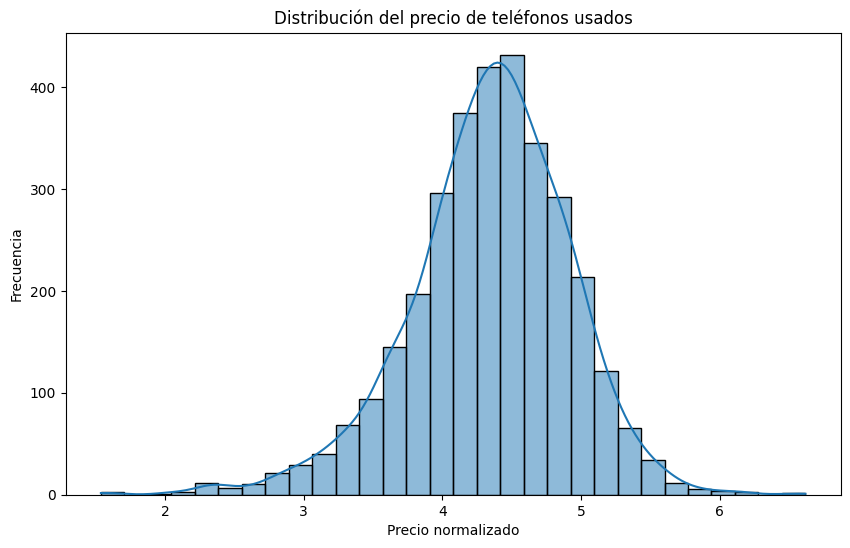

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(df_telefonos['normalized_used_price'],bins=30,kde=True)

plt.title('Distribución del precio de teléfonos usados')
plt.xlabel('Precio normalizado')
plt.ylabel('Frecuencia')

plt.show()

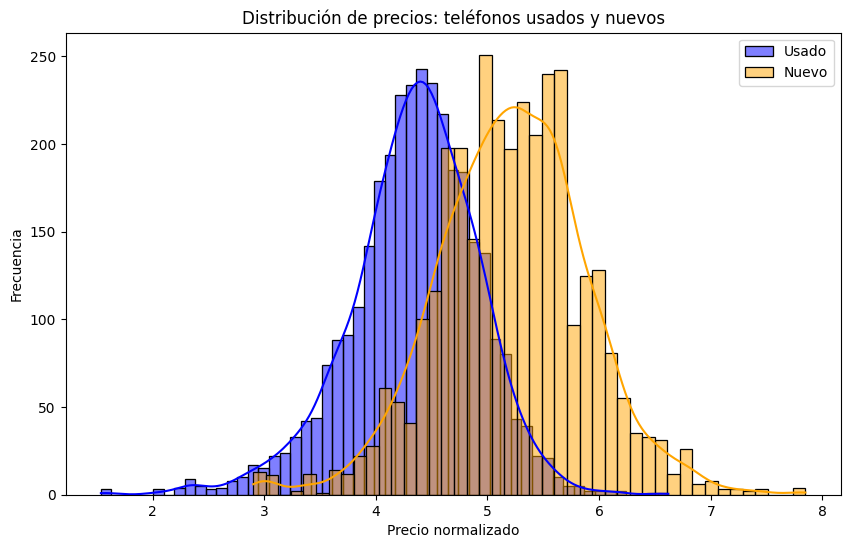

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df_telefonos['normalized_used_price'],color='blue',alpha=0.5,label='Usado',kde=True)

sns.histplot(df_telefonos['normalized_new_price'],color='orange',alpha=0.5,label='Nuevo',kde=True)

plt.title('Distribución de precios: teléfonos usados y nuevos')
plt.xlabel('Precio normalizado')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

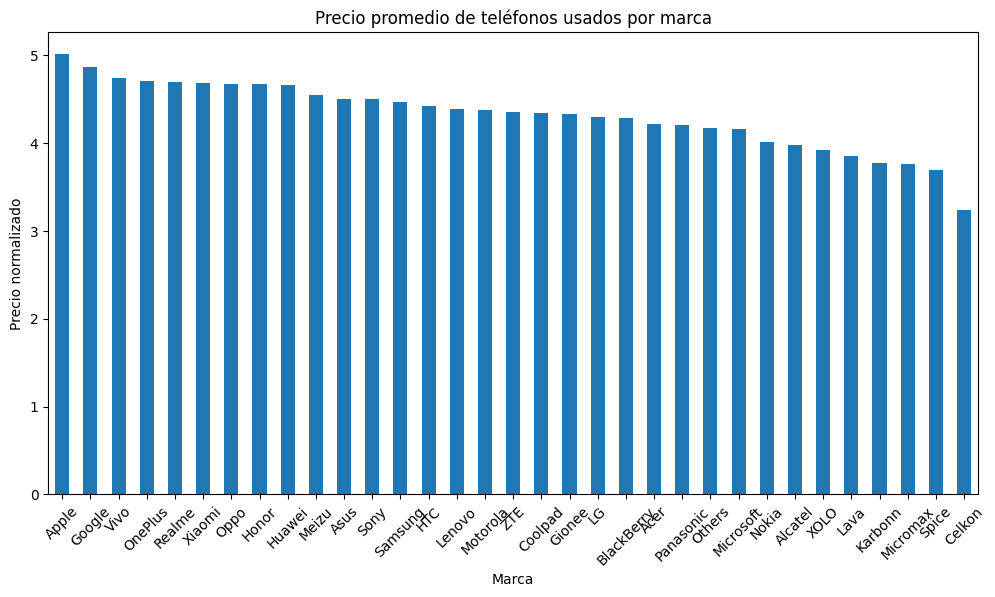

In [ ]:
plt.figure(figsize=(12,6))

precio_marca.plot(kind='bar')

plt.title('Precio promedio de teléfonos usados por marca')
plt.xlabel('Marca')
plt.ylabel('Precio normalizado')
plt.xticks(rotation=45)

plt.show()

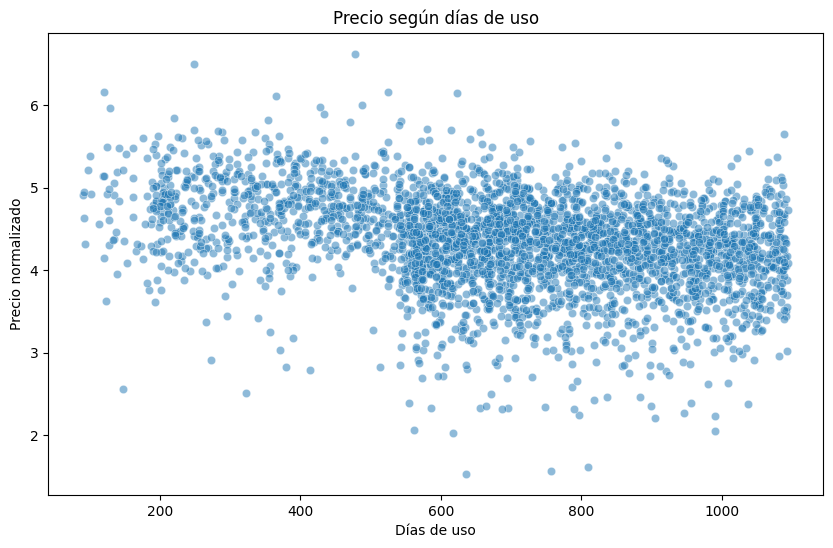

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df_telefonos,x='days_used',y='normalized_used_price',alpha=0.5)

plt.title('Precio según días de uso')
plt.xlabel('Días de uso')
plt.ylabel('Precio normalizado')

plt.show()